# Complex Exponentials, Euler's Formula & I/Q

Exploring complex exponentials, phasors, and the mathematical foundation of I/Q signals.

## Objective

In this notebook, we will:

- Understand Euler's formula
- Visualize complex exponentials
- Relate complex numbers to amplitude and phase
- Understand the basic idea of I/Q representation

## Theory

Euler's formula connects exponential functions with sine and cosine:

$$
e^{j\theta} = \cos(\theta) + j\sin(\theta)
$$

A complex sinusoid can therefore be represented as:

$$
z(t) = A e^{j(2\pi ft + \phi)}
$$

where:

- $A$ = amplitude
- $f$ = frequency
- $\phi$ = phase

The real and imaginary parts form the I/Q components:

$$
z(t) = I(t) + jQ(t)
$$

where:

- $I(t)$ = In-phase component
- $Q(t)$ = Quadrature component

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
theta = np.linspace(0, 2*np.pi, 1000)

z = np.exp(1j * theta)

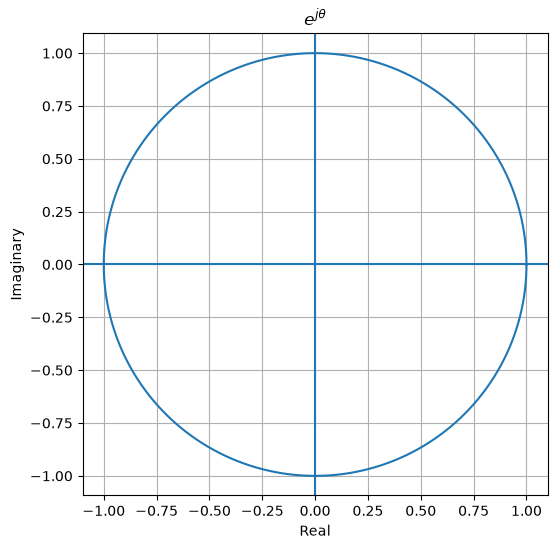

In [3]:
plt.figure(figsize=(6, 6))

plt.plot(z.real, z.imag)

plt.axhline(0)
plt.axvline(0)

plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title(r"$e^{j\theta}$")
plt.axis("equal")
plt.grid(True)

plt.show()

In [4]:
theta_test = np.pi / 4

z_test = np.exp(1j * theta_test)

print("Complex value:", z_test)
print("Real part:", z_test.real)
print("Imaginary part:", z_test.imag)

Complex value: (0.7071067811865476+0.7071067811865476j)
Real part: 0.7071067811865476
Imaginary part: 0.7071067811865476


## Observations

- The graph plots the unit chamber for real and imaginary numbers of magnitude of 1.
- x-axis shows real component magnitude and y-axis shows imaginary component magnitude.
- For pi/4, the graph should show real component of +0.707 and imaginary component of +0.707.

In [5]:
fs = 1000
duration = 1

t = np.arange(0, duration, 1/fs)

f = 10
phi = 0

z = np.exp(1j * (2*np.pi*f*t + phi))

I = z.real
Q = z.imag

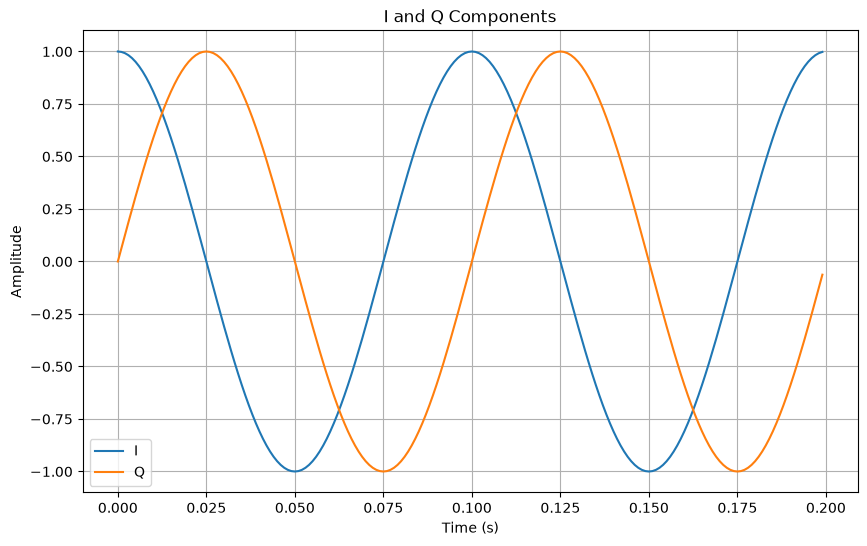

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(t[:200], I[:200], label="I")
plt.plot(t[:200], Q[:200], label="Q")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("I and Q Components")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- I part represents the real component and Q part represents the imaginary component.
- Q part lags 0.025 sn behind of I part due to pi/2 radiants phase difference on complex plane.

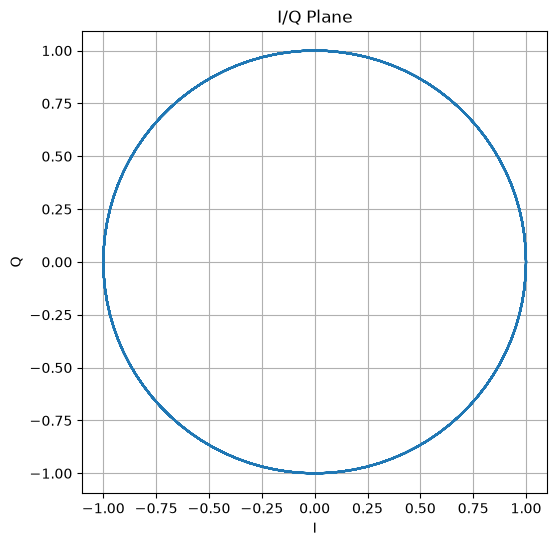

In [7]:
plt.figure(figsize=(6, 6))

plt.plot(I, Q)

plt.xlabel("I")
plt.ylabel("Q")
plt.title("I/Q Plane")

plt.axis("equal")
plt.grid(True)

plt.show()

## Observations

- The same signal is represented on I-Q plane.
- The signal having sinusoidal form on time-amplitude graph shapes a circular form on I-Q plane, since the signal periodically swings between -1 and 1 for both the real and imag. components on time-amp. graph. 

In [8]:
A = 2
phi = np.pi / 3
f = 10

z = A * np.exp(1j * (2*np.pi*f*t + phi))

I = z.real
Q = z.imag

In [9]:
magnitude = np.abs(z)
phase = np.angle(z)

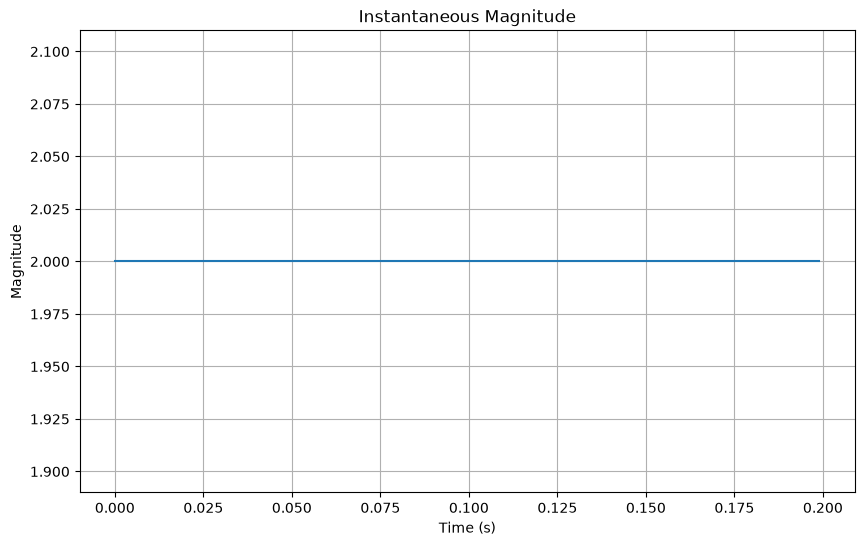

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(t[:200], magnitude[:200])

plt.xlabel("Time (s)")
plt.ylabel("Magnitude")
plt.title("Instantaneous Magnitude")
plt.grid(True)

plt.show()

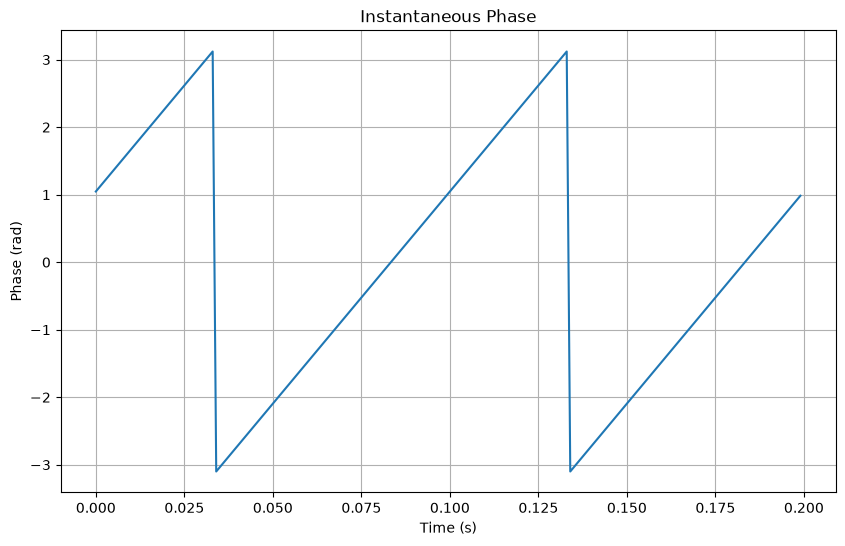

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(t[:200], phase[:200])

plt.xlabel("Time (s)")
plt.ylabel("Phase (rad)")
plt.title("Instantaneous Phase")
plt.grid(True)

plt.show()

## Observations

- The magnitude stays constant at 2 because the complex exponential only rotates in the complex plane. The phase increases continuously with time, but np.angle() represents it only between $-\pi$ and $\pi$, causing sudden jumps from approximately $\pi$ to $-\pi$.

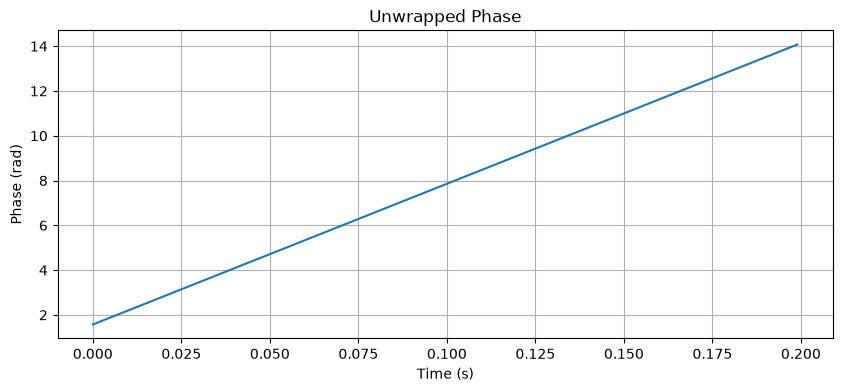

In [14]:
unwrapped_phase = np.unwrap(np.angle(z))

plt.figure(figsize=(10, 4))
plt.plot(t[:200], unwrapped_phase[:200])

plt.xlabel("Time (s)")
plt.ylabel("Phase (rad)")
plt.title("Unwrapped Phase")
plt.grid(True)

plt.show()

## Observations

- np.unwrap() removes these artificial phase jumps and shows the phase as a continuous, linearly increasing signal. This represents the actual continuous change of phase over time.

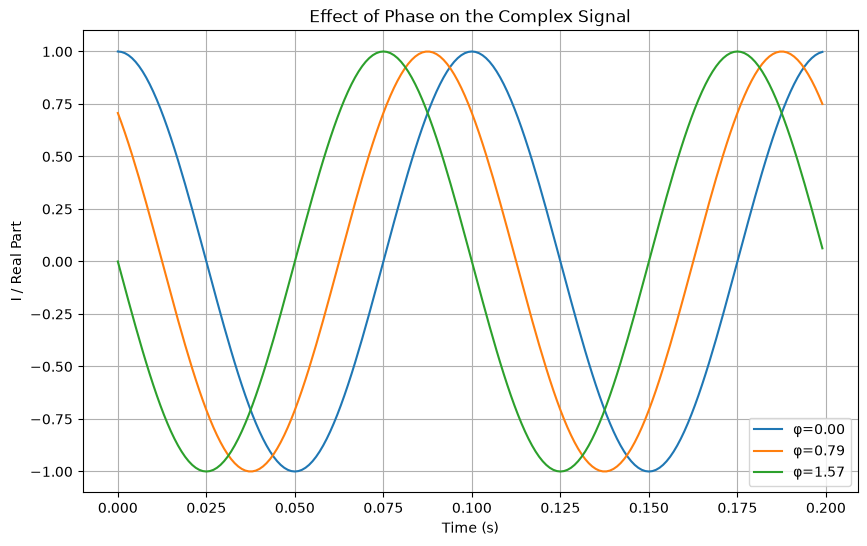

In [13]:
phases = [0, np.pi/4, np.pi/2]

plt.figure(figsize=(10, 6))

for phi in phases:
    z = np.exp(1j * (2*np.pi*10*t + phi))
    plt.plot(t[:200], z.real[:200], label=f"φ={phi:.2f}")

plt.xlabel("Time (s)")
plt.ylabel("I / Real Part")
plt.title("Effect of Phase on the Complex Signal")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- Phase difference affects the amount of lead or lag the signal will show relative to other signals, on time axis.

## Key Takeaways

- Euler's formula connects complex exponentials with sine and cosine:
[
e^{j\theta} = \cos(\theta) + j\sin(\theta)
]
- A complex signal can be represented as:
[
z(t)=I(t)+jQ(t)
]
where $I$ and $Q$ are the in-phase and quadrature components.
- The magnitude $|z|$ represents the signal amplitude, while the angle represents its phase.
- For a constant-amplitude complex sinusoid, the phase increases continuously with time because:
[
\theta(t)=2\pi ft+\phi
]
- np.angle() wraps the phase to the range $[-\pi,\pi)$, which creates apparent jumps. np.unwrap() reveals the continuous phase progression.
- The I/Q representation provides a convenient way to represent both amplitude and phase of a signal and forms an important mathematical basis for SDR.

## Next Step

Next, we will explore bandwidth, time-bandwidth trade-offs, and why short-duration signals have wider frequency spectra.